Practicar refuerza los conceptos vistos en los temas anteriores. Estos ejercicios combinan Matplotlib con NumPy, Pandas y Seaborn (para datasets integrados).

16.1 Gráficos de ventas
Ejercicio A – Ventas mensuales (línea)
Objetivo: visualizar tendencia y estacionalidad, anotando máximos y mínimos.

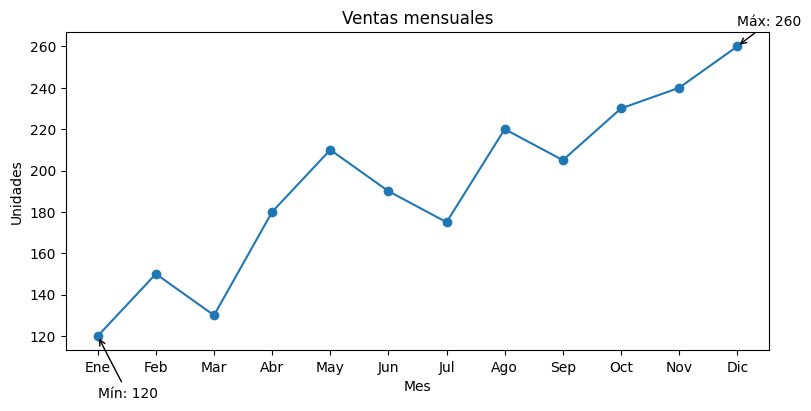

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

datos = {
    "mes": ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"],
    "ventas": [120, 150, 130, 180, 210, 190, 175, 220, 205, 230, 240, 260]
}
df = pd.DataFrame(datos).set_index("mes")

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
(line,) = ax.plot(df.index, df["ventas"], marker="o")

ax.set_title("Ventas mensuales")
ax.set_xlabel("Mes")
ax.set_ylabel("Unidades")

i_max = df["ventas"].idxmax()
v_max = df.loc[i_max, "ventas"]
i_min = df["ventas"].idxmin()
v_min = df.loc[i_min, "ventas"]

ax.annotate(f"Máx: {v_max}", xy=(i_max, v_max), xytext=(i_max, v_max + 10),
            arrowprops={"arrowstyle": "->"})
ax.annotate(f"Mín: {v_min}", xy=(i_min, v_min), xytext=(i_min, v_min - 30),
            arrowprops={"arrowstyle": "->"})

plt.show()

Ejercicio B – Ventas por categoría (barras)
Objetivo: comparar categorías, ordenando y etiquetando valores.

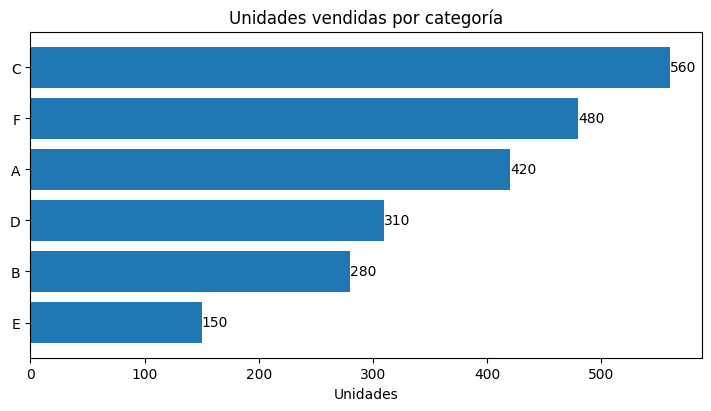

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "categoria": ["A", "B", "C", "D", "E", "F"],
    "unidades": [420, 280, 560, 310, 150, 480]
}).sort_values("unidades")

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
ax.barh(df["categoria"], df["unidades"])
ax.set_title("Unidades vendidas por categoría")
ax.set_xlabel("Unidades")

for y, v in zip(df["categoria"], df["unidades"]):
    ax.text(v, y, f"{v}", va="center", ha="left")

plt.show()

Ejercicio C – Ventas vs. Presupuesto (barras agrupadas)
Objetivo: comparar dos métricas por categoría y resaltar diferencias.

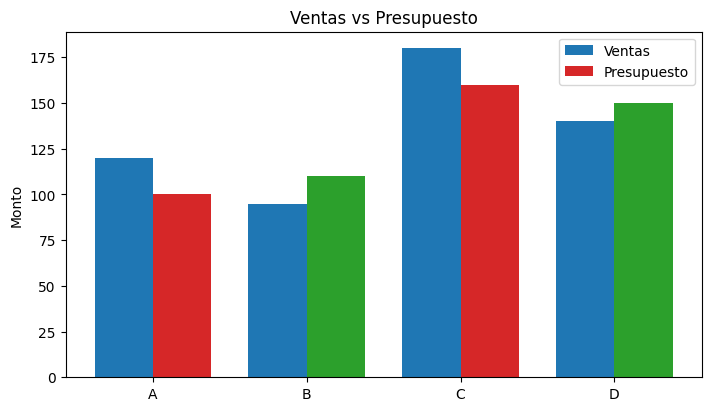

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "categoria": ["A", "B", "C", "D"],
    "ventas": [120, 95, 180, 140],
    "presupuesto": [100, 110, 160, 150]
})

x = np.arange(len(df))
width = 0.38

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
ax.bar(x - width / 2, df["ventas"], width=width, label="Ventas")
ax.bar(
    x + width / 2,
    df["presupuesto"],
    width=width,
    label="Presupuesto",
    color=["#2ca02c" if v <= p else "#d62728" for v, p in zip(df["ventas"], df["presupuesto"])]
)

ax.set_xticks(x, df["categoria"])
ax.set_title("Ventas vs Presupuesto")
ax.set_ylabel("Monto")
ax.legend()
plt.show()

16.2 Análisis de datasets clásicos
Titanic
Objetivo: analizar tasas de supervivencia y distribuciones de edad.

Enunciado: usá seaborn.load_dataset("titanic") para obtener el dataset (filtrá filas sin survived, pclass, sex o age), calculá la tasa de supervivencia por clase y sexo, representála con barras y construí un histograma superpuesto de edades diferenciando por supervivencia.

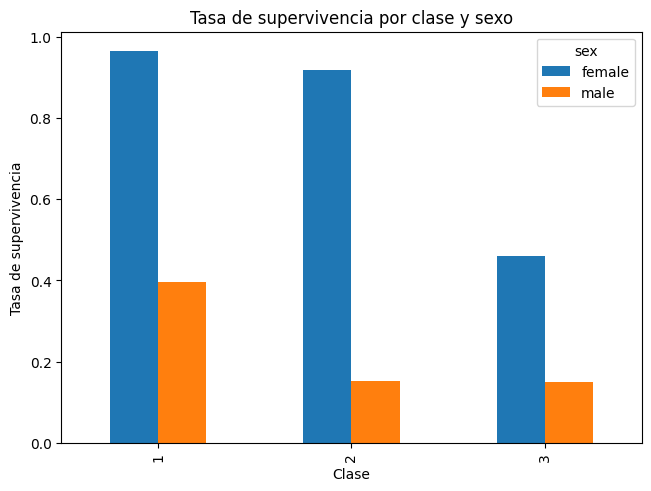

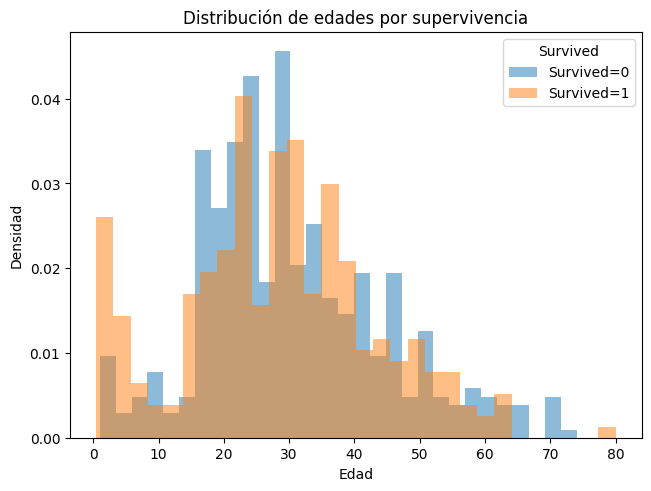

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic").dropna(subset=["survived", "pclass", "sex", "age"])
tasas = df.groupby(["pclass", "sex"])["survived"].mean().unstack()
fig, ax = plt.subplots(layout="constrained")
tasas.plot(kind="bar", ax=ax)
ax.set_title("Tasa de supervivencia por clase y sexo")
ax.set_xlabel("Clase")
ax.set_ylabel("Tasa de supervivencia")
plt.show()

fig, ax = plt.subplots(layout="constrained")
for survived, d in df.groupby("survived"):
    ax.hist(d["age"], bins=30, density=True, alpha=0.5, label=f"Survived={survived}")
ax.set_title("Distribución de edades por supervivencia")
ax.set_xlabel("Edad")
ax.set_ylabel("Densidad")
ax.legend(title="Survived")
plt.show()

16.3 Checklist de práctica
Propósito claro y título informativo.

Tipo de gráfico adecuado y comparaciones justas.

Estilo consistente (paleta, tipografías, grosores).

Exportación limpia (bbox_inches="tight", DPI apropiado).

Narrativa: cada gráfico responde una pregunta concreta.